# 01 - Análise exploratória

Primeiro contato com a base de preços médios do BLS (Kaggle: *US Grocery and Gas Prices 2015-2026*).
Objetivo aqui é entender o que dá e o que não dá para modelar antes de escrever o ETL.

Perguntas que guiaram a EDA:

1. As séries são completas? Onde estão os buracos?
2. As categorias do dataset fazem sentido?
3. Quais itens e categorias subiram mais, e quais são mais voláteis?
4. Existe sazonalidade forte em algum grupo?
5. A gasolina antecipa o movimento dos alimentos?

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FIGURES_DIR, SERIE_GASOLINA
from src.etl.extract import carregar_bruto
from src.etl.transform import padronizar
from src.etl.nomes_itens import NOMES_PT

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Visão geral

In [2]:
bruto = carregar_bruto()
print(bruto.shape)
bruto.head()

15:55:18 | INFO | src.etl.extract | Bruto: 8869 linhas, 74 séries


(8869, 8)


,date,year,month,item,unit,category,price,series_id
0,2015-01-01,2015,1,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.211,APU0000FD2101
1,2015-02-01,2015,2,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.221,APU0000FD2101
2,2015-03-01,2015,3,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.176,APU0000FD2101
3,2015-04-01,2015,4,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",2.971,APU0000FD2101
4,2015-05-01,2015,5,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.045,APU0000FD2101


In [3]:
bruto["date"] = pd.to_datetime(bruto["date"])
print("Período:", bruto["date"].min().date(), "a", bruto["date"].max().date())
print("Séries:", bruto["series_id"].nunique())
print("Nulos:", bruto.isna().sum().sum(), "| duplicadas (série, mês):", bruto.duplicated(["series_id", "date"]).sum())

Período: 2015-01-01 a 2026-07-01
Séries: 74
Nulos: 0 | duplicadas (série, mês): 0


## 2. Cobertura das séries

Sem nulos e sem duplicadas, mas isso engana: o arquivo longo simplesmente **não tem a linha** quando o BLS não publicou o preço. Precisamos olhar quantas séries existem em cada mês.

date
2025-08-01    63
2025-09-01    63
2025-10-01     3
2025-11-01    60
2025-12-01    63
2026-01-01    64
2026-02-01    62
2026-03-01    64
2026-04-01    64
2026-05-01    63
2026-06-01    61
2026-07-01    60
Name: series_id, dtype: int64

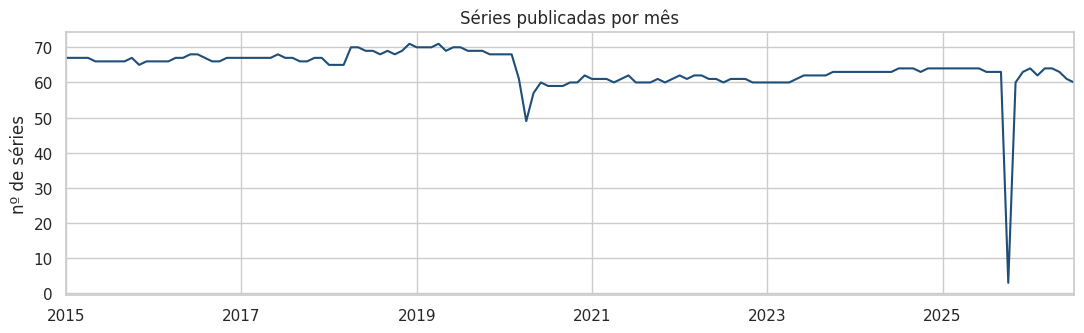

In [4]:
por_mes = bruto.groupby("date")["series_id"].nunique()
ax = por_mes.plot(figsize=(11, 3.5), color="#1f4e79")
ax.set_title("Séries publicadas por mês")
ax.set_xlabel("")
ax.set_ylabel("nº de séries")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_series_por_mes.png", dpi=120)
por_mes.tail(12)

Duas coisas aparecem:

- **Outubro/2025 tem só 3 séries.** Foi o mês da paralisação do governo americano (shutdown), e o BLS não coletou a maior parte dos preços. Só as gasolinas foram publicadas.
- As séries entram e saem em datas diferentes (queda em 2018-2022 e salto em abril/2018, quando entram as séries "All ..." e alguns laticínios).

Quantos meses faltam dentro do período de cada série:

In [5]:
cob = bruto.groupby(["series_id", "item"]).agg(inicio=("date", "min"), fim=("date", "max"), publicados=("price", "size")).reset_index()
cob["na_grade"] = (cob["fim"].dt.year - cob["inicio"].dt.year) * 12 + cob["fim"].dt.month - cob["inicio"].dt.month + 1
cob["faltando"] = cob["na_grade"] - cob["publicados"]
cob.sort_values("faltando", ascending=False).head(10)

,series_id,item,inicio,fim,publicados,na_grade,faltando
43,APU0000714221,"Corn, canned, any style, all sizes",2015-01-01,2026-07-01,37,139,102
14,APU0000703512,"Steak, round, graded and ungraded, excluding U...",2015-01-01,2026-04-01,67,136,69
32,APU0000711411,Grapefruit,2015-01-01,2026-07-01,96,139,43
38,APU0000712211,"Lettuce, iceberg",2015-01-01,2026-07-01,98,139,41
70,APU0000FL2101,"Lettuce, romaine",2015-01-01,2026-07-01,115,139,24
46,APU0000715212,"Sugar, white, 33-80 oz. pkg",2015-01-01,2022-10-01,70,94,24
33,APU0000711412,Lemons,2015-01-01,2026-07-01,120,139,19
48,APU0000717311,"Coffee, 100%, ground roast, all sizes",2015-01-01,2026-07-01,123,139,16
31,APU0000711311,"Oranges, Navel",2015-01-01,2026-06-01,125,138,13
12,APU0000703432,"Beef for stew, boneless",2015-01-01,2026-07-01,127,139,12


### Índice de completude

Para resumir a cobertura em um número: **índice de completude = meses publicados / meses esperados**. Calculamos de duas formas:

- **na vida da série:** meses entre o primeiro e o último preço publicado;
- **no período todo:** os 139 meses de jan/2015 a jul/2026 (penaliza séries que começaram tarde ou foram descontinuadas).

Meses no período: 139
Completude geral da base: 86.2%
Mediana por série (vida da série): 99.3%
completude_vida
< 75%      5
75-90%     4
90-99%    21
> 99%     44
Name: count, dtype: int64


,produto,publicados,na_grade,completude_vida,completude_total
43,Milho em lata,37,139,26.6,26.6
14,Bife de coxão sem classificação,67,136,49.3,48.2
32,Toranja (grapefruit),96,139,69.1,69.1
38,Alface americana,98,139,70.5,70.5
46,Açúcar (pacote 1-2 kg),70,94,74.5,50.4
34,Pera,31,38,81.6,22.3
70,Alface romana,115,139,82.7,82.7
33,Limão,120,139,86.3,86.3


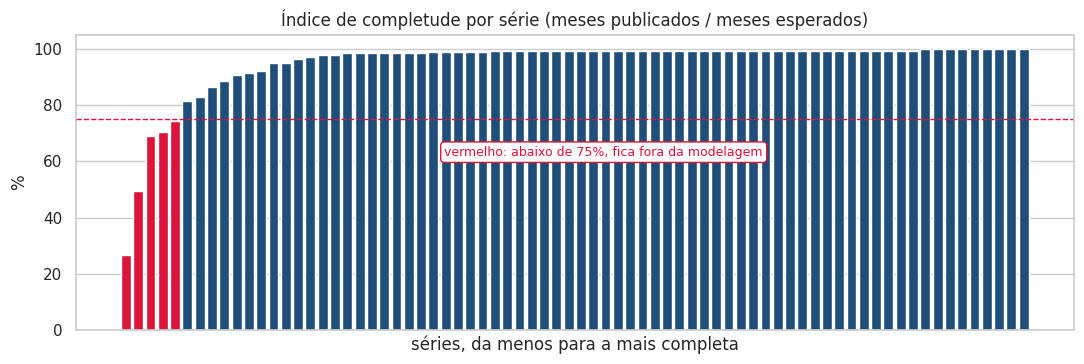

In [6]:
total_meses = (bruto["date"].max().year - bruto["date"].min().year) * 12 + bruto["date"].max().month - bruto["date"].min().month + 1
cob["completude_vida"] = cob["publicados"] / cob["na_grade"] * 100
cob["completude_total"] = cob["publicados"] / total_meses * 100

print(f"Meses no período: {total_meses}")
print(f"Completude geral da base: {cob['publicados'].sum() / (len(cob) * total_meses) * 100:.1f}%")
print(f"Mediana por série (vida da série): {cob['completude_vida'].median():.1f}%")

faixas = pd.cut(cob["completude_vida"], [0, 75, 90, 99, 100], labels=["< 75%", "75-90%", "90-99%", "> 99%"], include_lowest=True)
print(faixas.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(11, 3.8))
ordem = cob.sort_values("completude_vida")
cores = np.where(ordem["completude_vida"] < 75, "crimson", "#1f4e79")
ax.bar(range(len(ordem)), ordem["completude_vida"], color=cores)
ax.axhline(75, color="crimson", ls="--", lw=1)
ax.text(len(ordem) * 0.35, 62, "vermelho: abaixo de 75%, fica fora da modelagem", color="crimson", fontsize=9,
        bbox=dict(facecolor="white", edgecolor="crimson", boxstyle="round,pad=0.3"))
ax.set_xticks([])
ax.set_ylim(0, 105)
ax.set_title("Índice de completude por série (meses publicados / meses esperados)")
ax.set_ylabel("%")
ax.set_xlabel("séries, da menos para a mais completa")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_completude.png", dpi=120)
cob["produto"] = cob["series_id"].map(NOMES_PT)
cob.sort_values("completude_vida")[["produto", "publicados", "na_grade", "completude_vida", "completude_total"]].head(8).round(1)

A base como um todo tem **86% de completude** no período, mas isso é puxado por séries que começaram tarde ou foram descontinuadas. Olhando a vida de cada série, a mediana é **99%**: 44 das 74 séries têm mais de 99% dos meses, quase sempre faltando só out/2025 (shutdown). Cinco séries ficam abaixo de 75% e não entram no modelo, entre elas milho enlatado (27%), grapefruit (69%) e alface americana (71%).

In [7]:
print("Séries que pararam antes de 2026:", (cob["fim"] < "2026-01-01").sum())
cob[cob["fim"] < "2026-01-01"].sort_values("fim")[["item", "inicio", "fim", "publicados"]]

Séries que pararam antes de 2026: 10


,item,inicio,fim,publicados
9,"Chuck roast, graded and ungraded, excluding US...",2015-01-01,2017-12-01,36
34,"Pears, Anjou",2016-06-01,2019-07-01,31
21,"Bologna, all beef or mixed",2015-01-01,2019-09-01,57
47,"Margarine, soft, tubs",2015-01-01,2019-10-01,58
24,"Turkey, frozen, whole",2015-01-01,2020-02-01,62
40,"Peppers, sweet",2015-01-01,2020-03-01,58
41,Broccoli,2015-01-01,2020-03-01,63
36,"Grapes, Thompson Seedless",2015-01-01,2021-09-01,77
20,"Frankfurters, all meat or all beef",2015-10-01,2022-04-01,79
46,"Sugar, white, 33-80 oz. pkg",2015-01-01,2022-10-01,70


A maioria das séries tem só 1 ou 2 meses faltando (o shutdown). Mas algumas são quase inutilizáveis para série temporal: milho enlatado tem 102 meses faltando em 139, alface americana 41, grapefruit 43.

**Decisão para o ETL:** interpolar buracos curtos (até 2 meses) e deixar os longos vazios. Séries descontinuadas ou com mais de 25% de buracos ficam fora da modelagem, mas continuam no dashboard.

## 3. Categorias

In [8]:
bruto.groupby("category")["item"].unique().apply(lambda x: sorted(x)[:6])

category
Bakery and grains       [Bread, white, pan, Bread, whole wheat, pan, C...
Beef                    [All Uncooked Beef Steaks, All uncooked ground...
Dairy and fats          [American processed cheese, Butter, stick, Che...
Drinks                  [All soft drinks, All soft drinks, 12 pk, 12 o...
Eggs                                               [Eggs, grade A, large]
Energy                  [Automotive diesel fuel, Electricity, Fuel oil...
Fruit                   [Bananas, Grapefruit, Grapes, Thompson Seedles...
Meat, broad category    [All Ham (Excluding Canned Ham and Luncheon Sl...
Pantry and snacks       [Sugar, white, 33-80 oz. pkg, Sugar, white, al...
Pork and deli           [All Other Pork (Excluding Canned Ham and Lunc...
Poultry                 [Chicken breast, boneless, Chicken legs, bone-...
Vegetables              [Beans, dried, any type, all sizes, Broccoli, ...
Name: item, dtype: object

In [9]:
bruto.loc[bruto["item"].str.contains("Coffee|Potato chips|All Ham|Beef Roasts|Other Beef"), ["item", "category"]].drop_duplicates()

,item,category
0,All Ham (Excluding Canned Ham and Luncheon Sli...,"Meat, broad category"
407,All Uncooked Beef Roasts,"Meat, broad category"
683,All Uncooked Other Beef (Excluding Veal),"Meat, broad category"
3462,"Coffee, 100%, ground roast, all sizes",Beef
6925,Potato chips,Vegetables


O dataset tem erros de categoria: **café está como "Beef"** e **batata chips como "Vegetables"**. A categoria "Meat, broad category" mistura carne bovina com presunto.

Isso importa porque o dashboard vai agregar por categoria. Corrigimos no ETL (`CORRECOES_CATEGORIA` em `src/etl/transform.py`) e traduzimos os nomes.

In [10]:
df = padronizar(bruto)
df.groupby("categoria")["serie_id"].nunique().sort_values(ascending=False)

categoria
Carne bovina       14
Suínos e frios      9
Energia             8
Laticínios          8
Frutas              8
Hortaliças          8
Padaria e grãos     6
Bebidas             4
Aves                4
Mercearia           4
Ovos                1
Name: serie_id, dtype: int64

## 4. Quanto os preços subiram

Comparar o primeiro mês com o último é enganoso (sazonalidade, e no caso dos ovos um pico de gripe aviária no meio). Usamos a **média dos 12 primeiros meses contra a média dos 12 últimos**, só para séries que ainda são publicadas.

In [11]:
ultima = df["data"].max()
ativas = df.groupby("serie_id")["data"].max().loc[lambda s: s >= ultima - pd.DateOffset(months=2)].index

def variacao(s):
    s = s.sort_values("data")["preco"]
    return (s.iloc[-12:].mean() / s.iloc[:12].mean() - 1) * 100

var = (df[df["serie_id"].isin(ativas)]
       .groupby(["serie_id", "item", "categoria"]).apply(variacao, include_groups=False)
       .rename("variacao_pct").reset_index())
print(f"Séries ativas: {len(var)} | subiram: {(var['variacao_pct'] > 0).sum()} | mediana: {var['variacao_pct'].median():.1f}%")
pd.concat([var.nlargest(8, "variacao_pct"), var.nsmallest(5, "variacao_pct")])[["item", "categoria", "variacao_pct"]].round(1)

Séries ativas: 63 | subiram: 63 | mediana: 41.4%


,item,categoria,variacao_pct
37,"Coffee, 100%, ground roast, all sizes",Mercearia,96.3
33,"Orange juice, frozen concentrate, 12 oz. can",Frutas,77.9
43,Utility (piped) gas,Energia,77.4
59,"Lettuce, romaine",Hortaliças,70.6
52,All Uncooked Other Beef (Excluding Veal),Carne bovina,70.0
61,"All soft drinks, 12 pk, 12 oz., cans",Bebidas,69.2
13,"Steak, sirloin, USDA Choice, boneless",Carne bovina,64.9
41,Fuel oil #2,Energia,63.1
2,Spaghetti and macaroni,Padaria e grãos,0.1
28,Lemons,Frutas,2.8


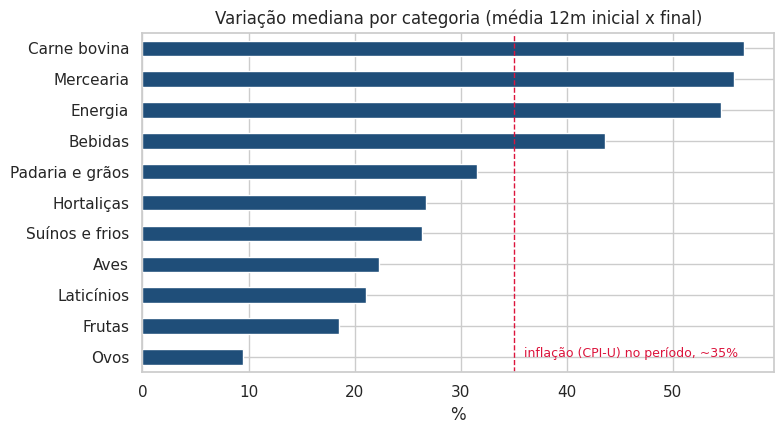

In [12]:
med_cat = var.groupby("categoria")["variacao_pct"].median().sort_values()
ax = med_cat.plot(kind="barh", figsize=(8, 4.5), color="#1f4e79")
ax.axvline(35, color="crimson", ls="--", lw=1)
ax.text(36, 0, "inflação (CPI-U) no período, ~35%", color="crimson", fontsize=9)
ax.set_title("Variação mediana por categoria (média 12m inicial x final)")
ax.set_xlabel("%")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_variacao_por_categoria.png", dpi=120)

Todas as 63 séries ativas subiram em termos nominais, mas algumas quase nada (macarrão +0,1%, limão +2,8%, manteiga +5,8%). Café praticamente dobrou.

Por categoria, carne bovina, mercearia (puxada pelo café) e energia ficam acima de 50%. Ovos (+9,5%), frutas, laticínios, aves, suínos e hortaliças ficaram **abaixo da inflação do período**, ou seja, ficaram mais baratos em termos reais. A mediana geral foi +41%.

## 5. Evolução no tempo

Índice por categoria: preço de cada série dividido pela média de 2019 (antes da pandemia), depois mediana dentro da categoria.

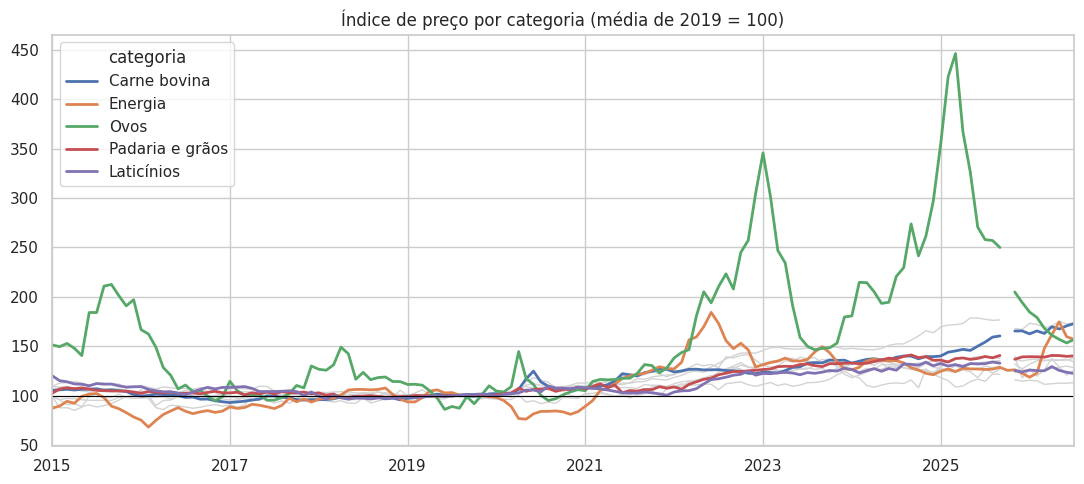

In [13]:
base19 = df[df["data"].dt.year == 2019].groupby("serie_id")["preco"].mean()
idx = df[df["serie_id"].isin(base19.index)].copy()
idx["indice"] = idx["preco"] / idx["serie_id"].map(base19) * 100
curva = idx.groupby(["data", "categoria"])["indice"].median().unstack()

fig, ax = plt.subplots(figsize=(11, 5))
destaque = ["Carne bovina", "Energia", "Ovos", "Padaria e grãos", "Laticínios"]
curva.drop(columns=destaque).plot(ax=ax, color="lightgray", legend=False, lw=1)
curva[destaque].plot(ax=ax, lw=2)
ax.axhline(100, color="black", lw=0.8)
ax.set_title("Índice de preço por categoria (média de 2019 = 100)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_indice_categorias.png", dpi=120)

O choque de 2022 aparece em todas as categorias, mas com formas diferentes: energia chega a 184 em meados de 2022, devolve quase tudo e volta a subir em 2026; carne bovina não devolve nada e segue subindo até 173. Ovos têm picos em 2015, na virada 2022/23 e no começo de 2025 (4,5 vezes o nível de 2019), todos ligados a surtos de gripe aviária. O buraco em out/2025 é o shutdown.

## 6. Volatilidade

Volatilidade mensal mediana: 2.8%


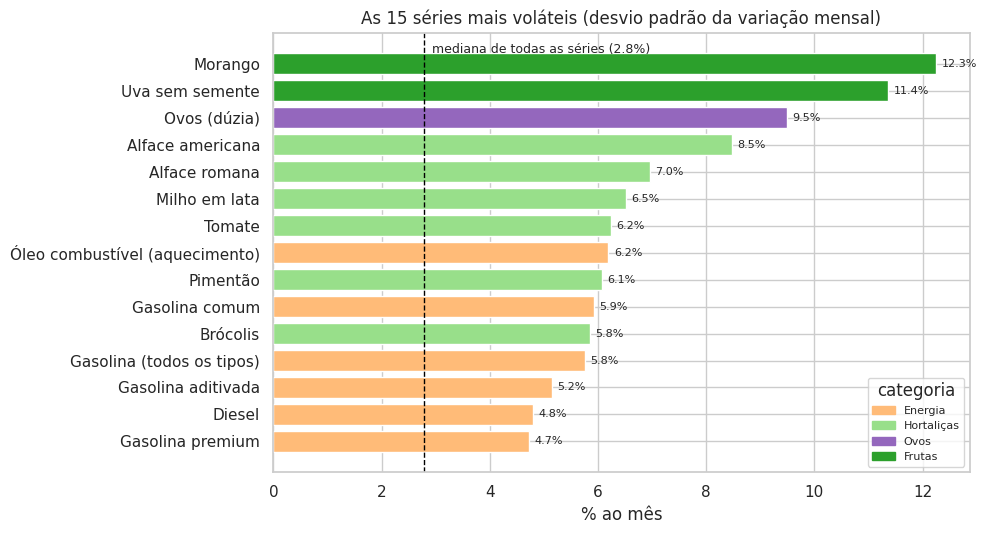

In [14]:
df = df.sort_values(["serie_id", "data"])
df["ret_1"] = df.groupby("serie_id")["preco"].transform(lambda s: np.log(s).diff())
vol = df.groupby(["serie_id", "categoria"])["ret_1"].std().mul(100).rename("vol_mensal_pct").reset_index()
vol["produto"] = vol["serie_id"].map(NOMES_PT)
vol = vol.sort_values("vol_mensal_pct", ascending=False)
print(f"Volatilidade mensal mediana: {vol['vol_mensal_pct'].median():.1f}%")

top = vol.head(15).iloc[::-1]
paleta = dict(zip(sorted(vol["categoria"].unique()), sns.color_palette("tab20", vol["categoria"].nunique())))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(top["produto"], top["vol_mensal_pct"], color=top["categoria"].map(paleta))
ax.axvline(vol["vol_mensal_pct"].median(), color="black", ls="--", lw=1)
ax.text(vol["vol_mensal_pct"].median() + 0.15, len(top) - 0.6, f"mediana de todas as séries ({vol['vol_mensal_pct'].median():.1f}%)", fontsize=9)
for y, v in enumerate(top["vol_mensal_pct"]):
    ax.text(v + 0.1, y, f"{v:.1f}%", va="center", fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=paleta[c]) for c in top["categoria"].unique()]
ax.legend(handles, top["categoria"].unique(), loc="lower right", fontsize=8, title="categoria")
ax.set_title("As 15 séries mais voláteis (desvio padrão da variação mensal)")
ax.set_xlabel("% ao mês")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_volatilidade.png", dpi=120)

In [15]:
vol.groupby("categoria")["vol_mensal_pct"].median().sort_values(ascending=False).round(1).rename("vol mediana (%)")

categoria
Ovos               9.5
Hortaliças         6.2
Energia            5.0
Frutas             4.0
Suínos e frios     2.8
Carne bovina       2.7
Aves               2.6
Padaria e grãos    2.4
Laticínios         2.2
Bebidas            2.2
Mercearia          2.1
Name: vol mediana (%), dtype: float64

mín: 2019-06-01 1.203 | máx: 2025-03-01 6.227


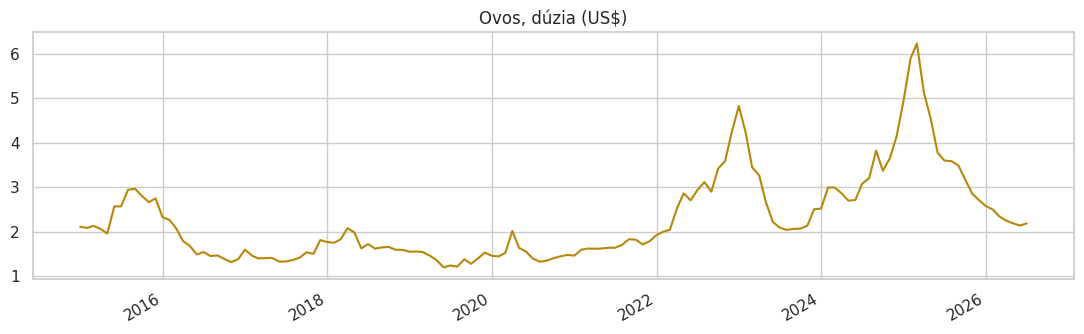

In [16]:
ovos = df[df["item"].str.startswith("Eggs")].set_index("data")["preco"]
ax = ovos.plot(figsize=(11, 3.5), color="#b8860b")
ax.set_title("Ovos, dúzia (US$)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_ovos.png", dpi=120)
print("mín:", ovos.idxmin().date(), ovos.min(), "| máx:", ovos.idxmax().date(), ovos.max())

A variação típica de uma série é 2,8% ao mês, mas o topo do ranking fica 3 a 4 vezes acima disso. Morango (12,3%) e uva (11,4%) lideram, e boa parte disso é sazonalidade (previsível). Ovos variam 9,5% ao mês, mais que qualquer combustível, e sem padrão sazonal: é choque de oferta. Depois vêm hortaliças (alface, tomate, pimentão) e os combustíveis.

Por categoria, ovos, hortaliças, energia e frutas ficam bem acima das demais, que oscilam entre 2% e 3% ao mês. Esses grupos vão dominar o erro de qualquer modelo; por isso vamos olhar as métricas também **por categoria**, não só no agregado.

## 7. Sazonalidade

Desvio médio de cada mês em relação à média móvel de 12 meses da própria série.

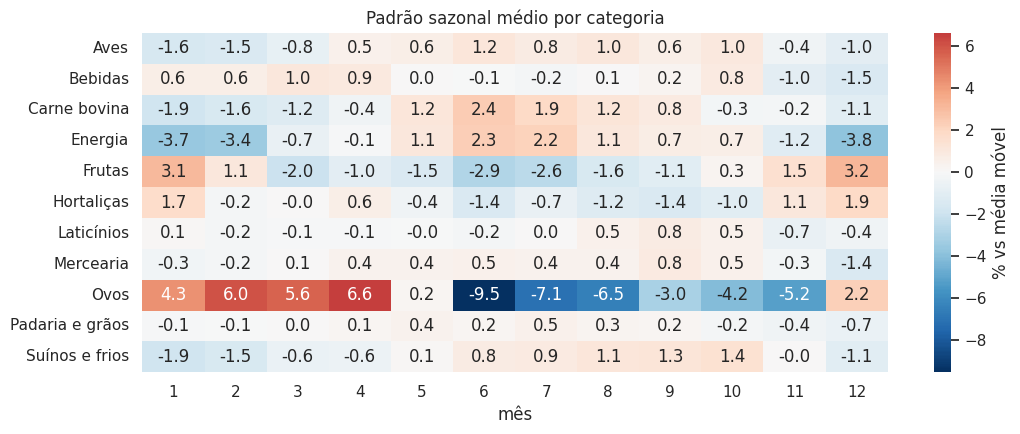

In [17]:
df["desvio_sazonal"] = df.groupby("serie_id")["preco"].transform(lambda s: np.log(s) - np.log(s.rolling(12, center=True).mean()))
df["mes"] = df["data"].dt.month
saz = df.groupby(["categoria", "mes"])["desvio_sazonal"].mean().mul(100).unstack()

plt.figure(figsize=(11, 4.5))
sns.heatmap(saz, cmap="RdBu_r", center=0, annot=True, fmt=".1f", cbar_kws={"label": "% vs média móvel"})
plt.title("Padrão sazonal médio por categoria")
plt.xlabel("mês")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_sazonalidade.png", dpi=120)

In [18]:
(df[df["categoria"] == "Frutas"].groupby(["item", "mes"])["desvio_sazonal"].mean().mul(100)
   .unstack().round(1))

mes,1,2,3,4,5,6,7,8,9,10,11,12
item,,,,,,,,,,,,
Bananas,0.2,0.1,0.8,0.5,0.7,0.4,-0.1,-0.3,-0.4,-0.7,-0.3,-0.4
Grapefruit,-5.0,-7.0,-3.9,-2.3,-0.8,2.0,3.6,3.3,4.5,7.3,2.4,-0.7
"Grapes, Thompson Seedless",15.1,12.6,5.3,10.4,21.5,0.1,-8.0,-16.5,-20.3,-17.2,-10.8,0.3
Lemons,-0.4,-1.4,-1.5,-1.0,-1.3,-0.9,1.9,1.7,2.6,1.3,0.5,-1.1
"Orange juice, frozen concentrate, 12 oz. can",-0.3,0.8,-0.5,0.3,0.4,1.4,1.7,1.3,-0.0,-0.6,-1.7,-1.1
"Oranges, Navel",-4.1,-4.7,-6.3,-6.4,-4.5,-0.9,4.2,8.5,8.7,10.2,4.0,-2.1
"Pears, Anjou",2.7,-2.4,-2.1,-2.8,-1.1,2.2,3.2,3.2,NaN,NaN,-1.7,-2.2
"Strawberries, dry pint",19.0,10.3,-5.1,-2.6,-12.3,-19.9,-19.8,-12.4,-7.0,-0.7,14.5,28.3


Frutas têm sazonalidade clara: morango fica ~20% mais barato em junho/julho e ~28% mais caro em dezembro; laranja faz o inverso (barata em março/abril, cara em agosto-outubro). Hortaliças e energia também têm algum padrão. Carnes, laticínios e padaria praticamente não têm.

Isso sugere features de sazonalidade: mês do alvo e "o que aconteceu nesta mesma janela no ano passado".

## 8. Gasolina antecipa alimentos?

Correlação entre a variação de 3 meses da gasolina e a variação de 3 meses de cada categoria, deslocando a gasolina de 0 a 9 meses para trás.

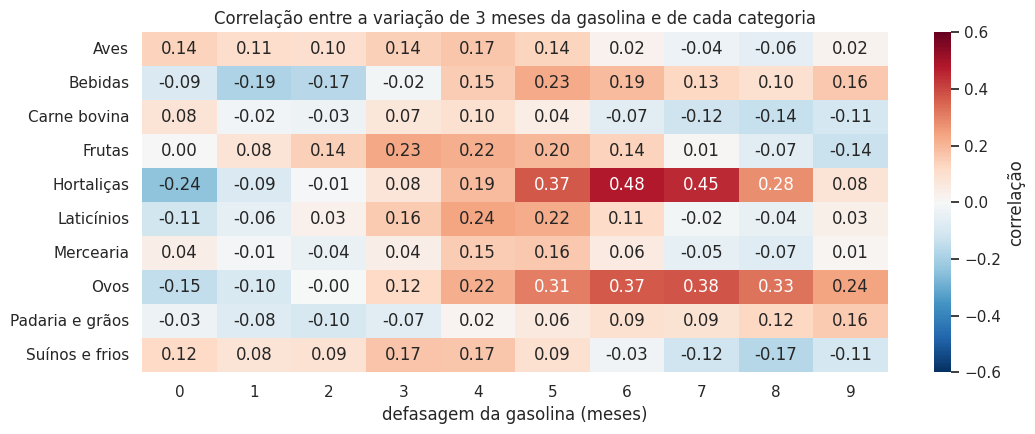

In [19]:
df["ret_3"] = df.groupby("serie_id")["preco"].transform(lambda s: np.log(s).diff(3))
gas = df[df["serie_id"] == SERIE_GASOLINA].set_index("data")["ret_3"]
cat_ret = df[df["categoria"] != "Energia"].groupby(["data", "categoria"])["ret_3"].median().unstack()

linhas = {}
for lag in range(0, 10):
    linhas[lag] = cat_ret.corrwith(gas.shift(lag))
corr = pd.DataFrame(linhas)

plt.figure(figsize=(11, 4.5))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6, annot=True, fmt=".2f",
            cbar_kws={"label": "correlação"})
plt.title("Correlação entre a variação de 3 meses da gasolina e de cada categoria")
plt.xlabel("defasagem da gasolina (meses)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_gasolina_correlacao.png", dpi=120)

A própria gasolina também tem padrão sazonal? Mesmo cálculo da seção 7 (desvio de cada mês em relação à média móvel de 12 meses), agora para as séries de combustível.

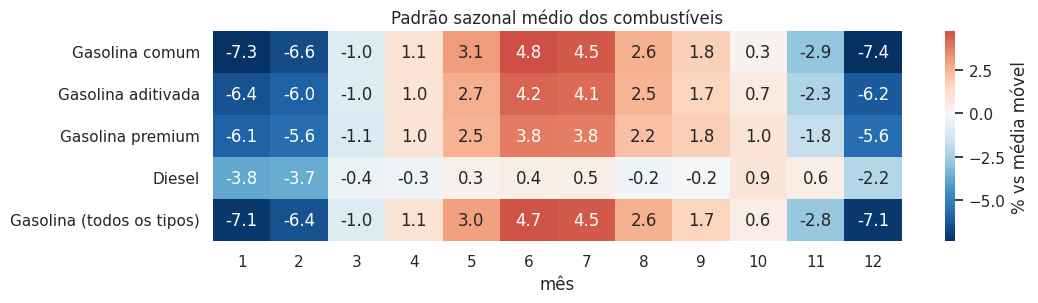

In [20]:
comb = df[df["item"].str.contains("Gasoline|Diesel", case=False)]
saz_comb = comb.groupby(["serie_id", "mes"])["desvio_sazonal"].mean().mul(100).unstack()
saz_comb.index = saz_comb.index.map(NOMES_PT)

plt.figure(figsize=(11, 3.2))
sns.heatmap(saz_comb, cmap="RdBu_r", center=0, annot=True, fmt=".1f", cbar_kws={"label": "% vs média móvel"})
plt.title("Padrão sazonal médio dos combustíveis")
plt.xlabel("mês")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_gasolina_sazonalidade.png", dpi=120)

**Correlação com os alimentos:** na defasagem zero é praticamente nula. Ela aparece com atraso: hortaliças chegam a 0,48 com 6 meses de defasagem e ovos a 0,38 com 7 (pode ser só coincidência dos ciclos de 2022; correlação não é causa). Nas carnes e na padaria é fraca.

**Sazonalidade da gasolina:** tem um padrão claro e parecido nos quatro tipos. Fica cerca de 7% abaixo da média em dezembro e janeiro e cerca de 5% acima em junho e julho, a temporada de viagens de carro no verão americano. O diesel tem padrão bem mais fraco (no máximo 4%).

A gasolina não é um preditor forte sozinha, mas é barata de incluir (variação de 3 e 12 meses) e o modelo decide se usa.

## 9. Conclusões da EDA

- **Base pequena e larga:** 74 séries x 139 meses. Um modelo por série teria pouquíssimos dados; faz mais sentido **um modelo global** para todas as séries, prevendo a variação percentual (em log) em vez do preço em dólar.
- **Buracos:** outubro/2025 (shutdown) em quase todas as séries; interpolar buracos de até 2 meses. Descartar da modelagem as séries descontinuadas (10 pararam antes de 2026, e o *Steak, round, graded and ungraded* parou em abril/2026) e as 3 com buracos demais.
- **Categorias do dataset têm erros** (café como carne bovina). Corrigidas no ETL.
- **Heterogeneidade:** ovos e energia são muito voláteis; aves e padaria quase não mexem. Métrica por categoria é obrigatória.
- **Sazonalidade** relevante em frutas, hortaliças e energia.
- **Horizonte:** vamos prever **3 meses à frente**. Com 1 mês, repetir o último preço já é difícil de bater e a previsão tem pouca utilidade prática; com 6 o erro cresce muito.
- Qualquer modelo precisa ser comparado com o **ingênuo** (preço de daqui a 3 meses = preço de hoje). Se não ganhar dele, não serve.